설정된 그래프 규모: 노드 수(V) = 4,461개, 엣지 수(E) = 25,918개

[실험 1] 인접 행렬 vs 인접 리스트 공간 복잡도 및 가상 메모리 측정
- 인접 행렬 메모리 사용량: 152.10 MB (초기화 속도: 0.0832초)
- 인접 리스트 메모리 사용량: 0.64 MB (초기화 및 엣지 삽입 속도: 0.1048초)
-> 결론: 인접 리스트가 메모리를 약 236.1배 더 아꼈습니다.

[실험 2] Max-Heap (추천 상위 K개 추출) vs 전체 정렬 속도 측정
후보 도서 수(N) = 4000개 일 때, Top-K 값 변화에 따른 수행 시간(초):
  - Top-5   | 전체 정렬: 0.000621초 | Heap 추출: 0.000185초 (3.4배 빠름)
  - Top-10  | 전체 정렬: 0.000621초 | Heap 추출: 0.000221초 (2.8배 빠름)
  - Top-20  | 전체 정렬: 0.000621초 | Heap 추출: 0.000213초 (2.9배 빠름)
  - Top-50  | 전체 정렬: 0.000621초 | Heap 추출: 0.000225초 (2.8배 빠름)
  - Top-100 | 전체 정렬: 0.000621초 | Heap 추출: 0.000290초 (2.1배 빠름)

[성공] 벤치마크 결과 그래프가 'recommender_system_benchmark.png'로 저장되었습니다.


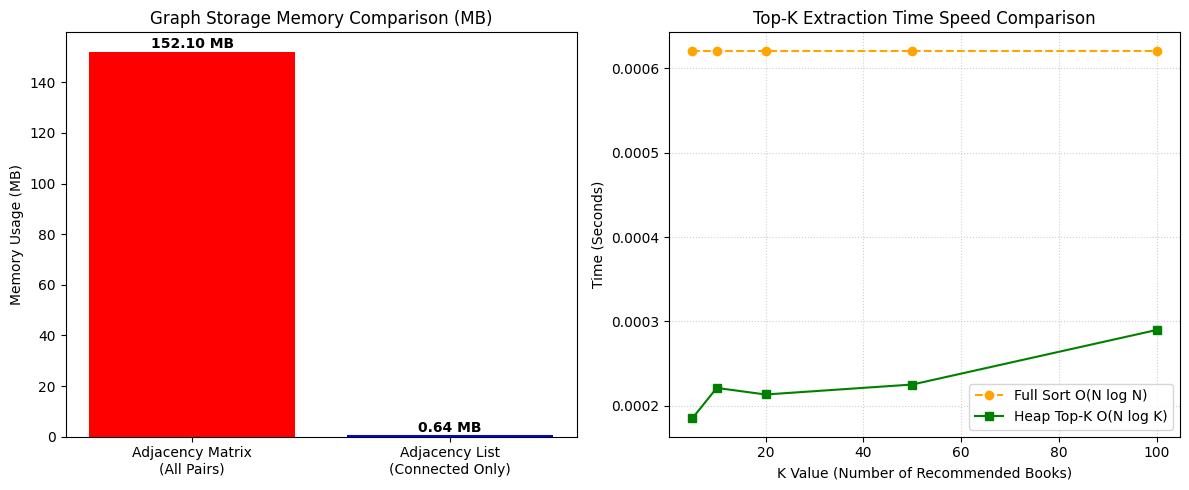

In [1]:
import time
import sys
import random
import heapq
# 시각화를 위한 라이브러리 (필요 시 설치: pip install matplotlib)
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

# -------------------------------------------------------------------------
# 실험 데이터 설정 (제공된 정보나루 co-loan 데이터 규격 반영)
# -------------------------------------------------------------------------
NUM_NODES = 4461      # V: 노드 수
NUM_EDGES = 25918     # E: 엣지 수

print("=" * 60)
print(# 데이터 기반 도서 추천 시스템 비교 실험 설정
f"설정된 그래프 규모: 노드 수(V) = {NUM_NODES:,}개, 엣지 수(E) = {NUM_EDGES:,}개")
print("=" * 60)

# -------------------------------------------------------------------------
# 실험 1: 인접 행렬 (Adjacent Matrix) vs 인접 리스트 (Adjacent List)
# -------------------------------------------------------------------------
def run_experiment_1():
    print("\n[실험 1] 인접 행렬 vs 인접 리스트 공간 복잡도 및 가상 메모리 측정")
    
    # 1. 인접 행렬 생성 (V x V 가상 공간 체감)
    # 실제 4461 x 4461의 0으로 가득 찬 2차원 리스트 생성
    start_time = time.time()
    adj_matrix = [[0] * NUM_NODES for _ in range(NUM_NODES)]
    matrix_init_time = time.time() - start_time
    
    # 파이썬 리스트 내부 객체 오버헤드를 고려한 대략적인 크기 계산
    # (파이썬에서 리스트 자체의 크기와 내부 원소 포인터 크기 반영)
    matrix_memory = sys.getsizeof(adj_matrix) + sum(sys.getsizeof(row) for row in adj_matrix)
    
    # 2. 인접 리스트 생성 (실제 엣지만 저장)
    start_time = time.time()
    adj_list = {i: [] for i in range(NUM_NODES)}
    # 무작위로 25,918개의 연관 대출(엣지) 연결 시뮬레이션
    edges_created = 0
    while edges_created < NUM_EDGES:
        u = random.randint(0, NUM_NODES - 1)
        v = random.randint(0, NUM_NODES - 1)
        if u != v and v not in adj_list[u]:
            weight = random.randint(1, 10)
            adj_list[u].append((v, weight))
            edges_created += 1
    list_init_time = time.time() - start_time
    
    list_memory = sys.getsizeof(adj_list) + sum(sys.getsizeof(adj_list[i]) for i in adj_list)
    
    # 결과 출력
    matrix_mb = matrix_memory / (1024 * 1024)
    list_mb = list_memory / (1024 * 1024)
    
    print(f"- 인접 행렬 메모리 사용량: {matrix_mb:.2f} MB (초기화 속도: {matrix_init_time:.4f}초)")
    print(f"- 인접 리스트 메모리 사용량: {list_mb:.2f} MB (초기화 및 엣지 삽입 속도: {list_init_time:.4f}초)")
    print(f"-> 결론: 인접 리스트가 메모리를 약 {matrix_mb / list_mb:.1f}배 더 아꼈습니다.")
    
    return matrix_mb, list_mb


# -------------------------------------------------------------------------
# 실험 2: Max-Heap (상위 K개 추출) vs 전체 정렬 (Full Sort) 속도 비교
# -------------------------------------------------------------------------
def run_experiment_2():
    print("\n[실험 2] Max-Heap (추천 상위 K개 추출) vs 전체 정렬 속도 측정")
    
    # 추천 후보 도서 리스트 가상 생성 (추천 점수가 무작위로 매겨진 N개의 도서 데이터)
    # BFS 탐색 결과 모인 후보군 리스트의 크기 N (여기서는 전체 노드 수에 근접한 4000개로 가정)
    N = 4000
    K_values = [5, 10, 20, 50, 100] # 추천 도서 개수 Top-N의 K값들
    
    # 무작위 점수를 가진 후보 데이터 (score, book_id)
    dummy_candidates = [(random.random(), i) for i in range(N)]
    
    heap_times = []
    sort_times = []
    
    # 1. 전체 정렬 (Full Sort) 성능 측정 - O(N log N)
    # 정렬은 K값과 관계없이 항상 전체 리스트를 정렬해야 함
    start_time = time.time()
    for _ in range(100): # 신뢰도를 위해 100번 반복 측정
        sorted_res = sorted(dummy_candidates, key=lambda x: x[0], reverse=True)
        _ = sorted_res[:100] # 임의의 Top-K 추출
    full_sort_time_avg = (time.time() - start_time) / 100
    
    # 2. Heap 기반 추출 성능 측정 - O(N log K)
    # 파이썬 heapq는 Min-Heap이므로 상위 최대값을 유지하기 위해 크기가 K인 힙 유지
    print(f"후보 도서 수(N) = {N}개 일 때, Top-K 값 변화에 따른 수행 시간(초):")
    
    for K in K_values:
        start_time = time.time()
        for _ in range(100): # 100번 반복 측정
            # heapq.nlargest(K)는 내부적으로 크기 K의 최적화된 구조를 사용합니다.
            top_k_heap = heapq.nlargest(K, dummy_candidates, key=lambda x: x[0])
        avg_heap_time = (time.time() - start_time) / 100
        
        heap_times.append(avg_heap_time)
        sort_times.append(full_sort_time_avg) # 정렬 시간은 K와 무관하게 동일함
        
        speedup = full_sort_time_avg / avg_heap_time
        print(f"  - Top-{K:<3} | 전체 정렬: {full_sort_time_avg:.6f}초 | Heap 추출: {avg_heap_time:.6f}초 ({speedup:.1f}배 빠름)")
        
    return K_values, sort_times, heap_times


# -------------------------------------------------------------------------
# 시각화 결과 생성 그래프 저장 함수
# -------------------------------------------------------------------------
def plot_results(matrix_mb, list_mb, K_values, sort_times, heap_times):
    if not MATPLOTLIB_AVAILABLE:
        print("\n[안내] matplotlib 라이브러리가 없어 시각화 그래프 파일 생성을 건너뜁니다.")
        return

    plt.figure(figsize=(12, 5))

    # 그래프 1: 메모리 비교
    plt.subplot(1, 2, 1)
    bars = plt.bar(['Adjacency Matrix\n(All Pairs)', 'Adjacency List\n(Connected Only)'], [matrix_mb, list_mb], color=['red', 'blue'])
    plt.title('Graph Storage Memory Comparison (MB)')
    plt.ylabel('Memory Usage (MB)')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f'{yval:.2f} MB', ha='center', va='bottom', fontweight='bold')

    # 그래프 2: 속도 비교
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sort_times, label='Full Sort O(N log N)', color='orange', marker='o', linestyle='--')
    plt.plot(K_values, heap_times, label='Heap Top-K O(N log K)', color='green', marker='s')
    plt.title('Top-K Extraction Time Speed Comparison')
    plt.xlabel('K Value (Number of Recommended Books)')
    plt.ylabel('Time (Seconds)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('recommender_system_benchmark.png')
    print("\n[성공] 벤치마크 결과 그래프가 'recommender_system_benchmark.png'로 저장되었습니다.")

# 실행
if __name__ == '__main__':
    mat_mb, li_mb = run_experiment_1()
    k_val, s_time, h_time = run_experiment_2()
    plot_results(mat_mb, li_mb, k_val, s_time, h_time)